In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np

In [2]:
def plot_3d(axs, filename, maxdb, maxdg, maxp):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_unequal.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    energies = np.array(energies)
    print(np.min(np.min(energies, axis=1), axis=1))

    norm = colors.Normalize(vmin=0, vmax=np.max(energies))
    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))] 
    
    print(
        [
            (
                round(delta_bs[np.unravel_index(np.argmin(energies[plot_ps[i],:,:]), energies[plot_ps[i],:,:].shape)[0]],2), 
                round(delta_gs[np.unravel_index(np.argmin(energies[plot_ps[i],:,:]), energies[plot_ps[i],:,:].shape)[1]],2)
            ) 
            for i in range(len(axs)) 
        ]
    ) 
    
      
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(np.log10(delta_bs), np.log10(delta_gs), energies[plot_ps[i],:,:].T, shading='nearest', norm=norm)
        ix, iy = np.unravel_index(np.argmin(energies[plot_ps[i],:,:]), energies[plot_ps[i],:,:].shape)
        x_max = np.log10(delta_bs)[ix]
        y_max = np.log10(delta_gs)[iy]
        ax.plot(
            x_max, y_max,
            marker='x',
            color='red',
            markersize=8,
            # markeredgecolor='white',
            zorder=10
        )
        ax.set_xlabel(r'$\log(\Delta_\beta)$')
        ax.set_ylabel(r'$\log(\Delta_\gamma)$')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$H_C$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=10)
    return axs

[1.90125e+01 9.26950e+00 4.79925e+00 1.64300e+00 2.02750e-01 1.62500e-02]
[(np.float64(0.79), np.float64(0.1)), (np.float64(0.5), np.float64(0.1)), (np.float64(0.5), np.float64(0.13)), (np.float64(0.5), np.float64(0.16)), (np.float64(0.32), np.float64(0.1)), (np.float64(0.25), np.float64(0.1))]
[9.605800e+01 2.662325e+01 1.260525e+01 5.016750e+00 1.235000e+00
 1.850000e-02]
[(np.float64(2.51), np.float64(0.1)), (np.float64(0.5), np.float64(0.1)), (np.float64(0.5), np.float64(0.1)), (np.float64(0.4), np.float64(0.16)), (np.float64(0.79), np.float64(0.13)), (np.float64(0.79), np.float64(0.13))]


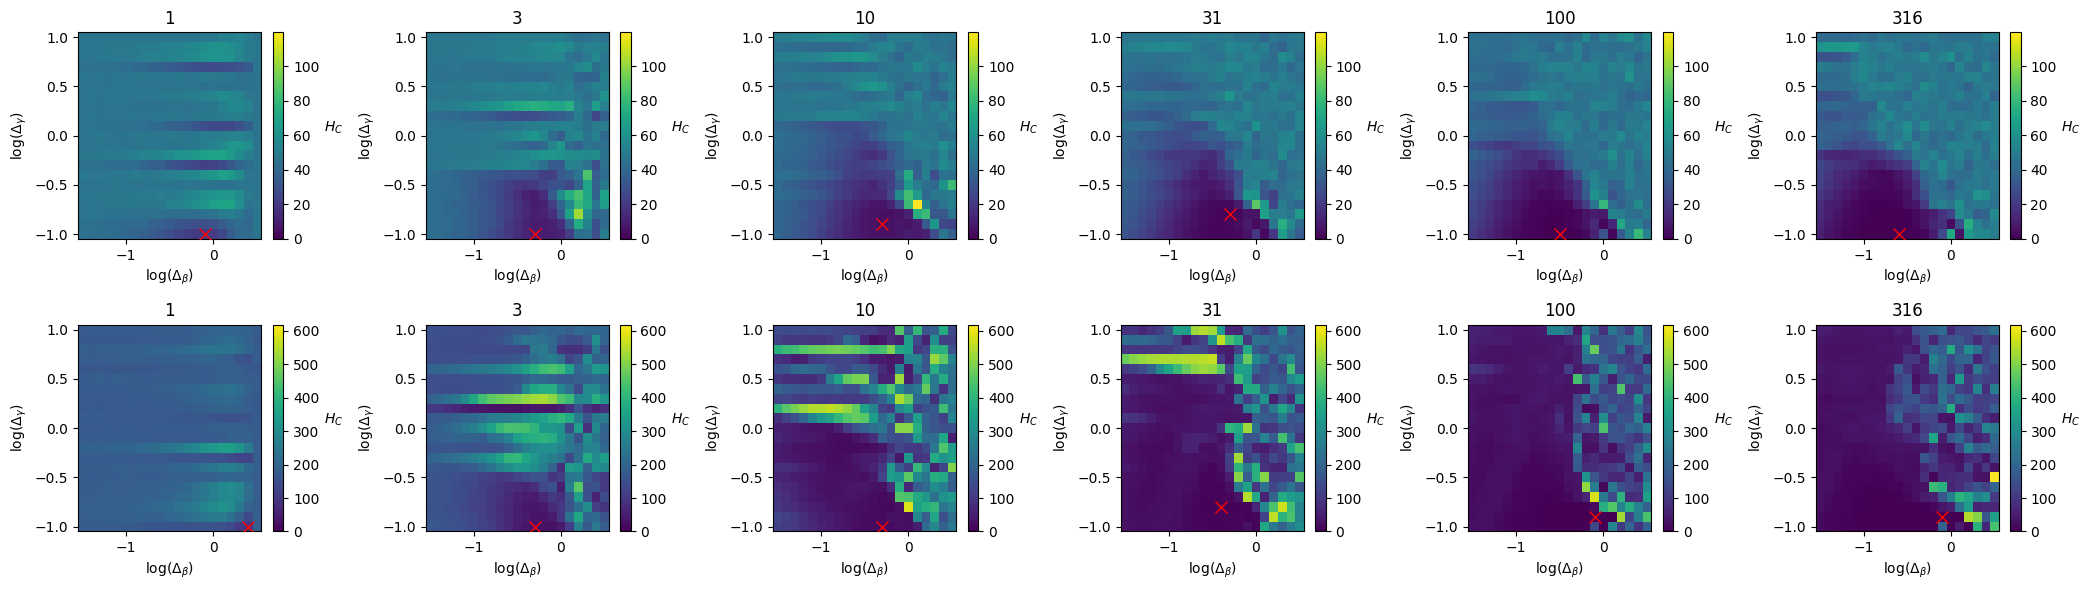

In [3]:
fig, axs = plt.subplots(2, 6)
db = 3.16
dg = 10.0
maxp = 316
plot_3d(axs[0, :], 'test_N2_W2', db, dg, maxp)
plot_3d(axs[1, :], 'trivial', db, dg, maxp)
# plot_p_opt_3d(axs[2, :], 'test_N7_W2', db, dg, maxp)
# plot_p_opt_3d(axs[3, :], 'test_N8_W3', db, dg, maxp)



fig.set_figheight(3 * len(axs[:,0]))
fig.set_figwidth(3.5 * len(axs[0,:]))
plt.tight_layout()

In [4]:
def plot_p_opt_3d(axs, filename, maxdb, maxdg, maxp, qubits):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_unequal.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    p_opts = res['p_opts']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    p_opts = np.array(p_opts)
    print(np.max(np.max(p_opts, axis=1), axis=1))

    norm = colors.Normalize(vmin=-qubits, vmax=np.log2(np.max(p_opts)))
    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))] 
    cmap = plt.get_cmap()
    cmap.set_over('yellow')
    cmap.set_under('black')

    
    print(
        [
            (
                round(delta_bs[np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)[0]],2), 
                round(delta_gs[np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)[1]],2)
            ) 
            for i in range(len(axs)) 
        ]
    ) 
    
      
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(np.log10(delta_bs), np.log10(delta_gs), np.log2(p_opts[plot_ps[i],:,:].T), shading='nearest', cmap=cmap, norm=norm)
        ix, iy = np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)
        x_max = np.log10(delta_bs)[ix]
        y_max = np.log10(delta_gs)[iy]
        ax.plot(
            x_max, y_max,
            marker='x',
            color='red',
            markersize=8,
            # markeredgecolor='white',
            zorder=10
        )
        ax.set_xlabel(r'$\log(\Delta_\beta)$')
        ax.set_ylabel(r'$\log(\Delta_\gamma)$')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$\log_2(p_{\text{opt}})$'
        cbar.ax.set_ylabel(label, rotation=90, va="bottom", labelpad=15)
    return axs

[0.1395  0.1905  0.442   0.83275 0.98125 0.9985 ]
[(np.float64(1.26), np.float64(1.26)), (np.float64(0.63), np.float64(0.2)), (np.float64(0.79), np.float64(0.16)), (np.float64(0.5), np.float64(0.2)), (np.float64(0.4), np.float64(0.1)), (np.float64(0.25), np.float64(0.1))]
[0.002   0.01525 0.131   0.4135  0.79625 0.99725]
[(np.float64(1.26), np.float64(0.5)), (np.float64(0.5), np.float64(0.13)), (np.float64(0.63), np.float64(0.2)), (np.float64(0.79), np.float64(0.16)), (np.float64(0.4), np.float64(0.16)), (np.float64(1.0), np.float64(0.13))]


/tmp/ipykernel_2401935/402752290.py:31: RuntimeWarning: divide by zero encountered in log2
  im = ax.pcolormesh(np.log10(delta_bs), np.log10(delta_gs), np.log2(p_opts[plot_ps[i],:,:].T), shading='nearest', cmap=cmap, norm=norm)


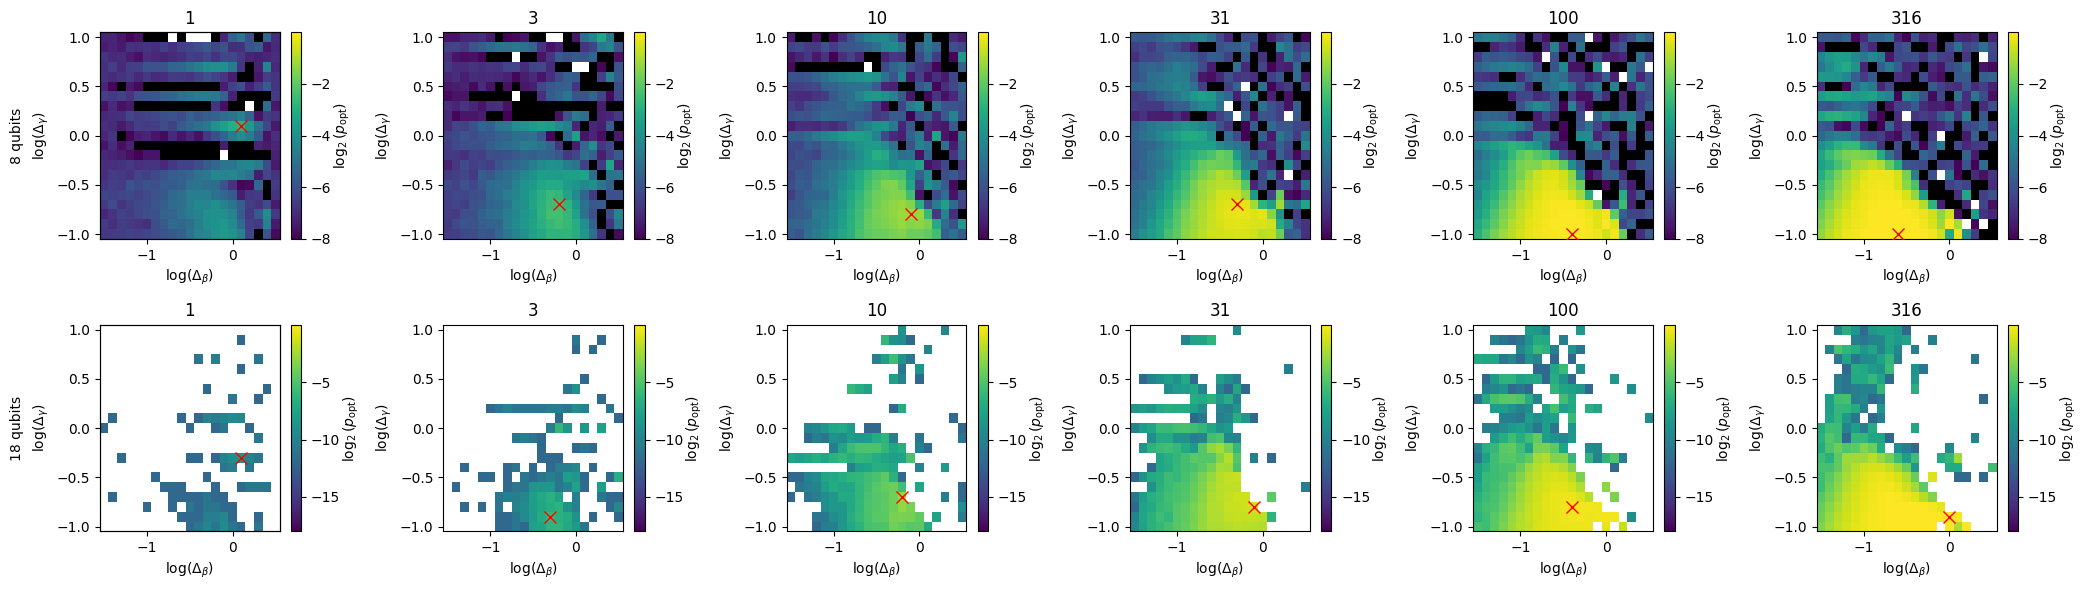

In [5]:
fig, axs = plt.subplots(2, 6)
db = 3.16
dg = 10.0
maxp = 316
qubits = [8, 18]
plot_p_opt_3d(axs[0, :], 'test_N2_W2', db, dg, maxp, qubits[0])
plot_p_opt_3d(axs[1, :], 'trivial', db, dg, maxp, qubits[1])
# plot_p_opt_3d(axs[2, :], 'test_N3_W4', db, dg, maxp)
# plot_p_opt_3d(axs[3, :], 'test_N8_W3', db, dg, maxp)
qubits = [8, 18]
for idx, ax in enumerate(axs[:, 0]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    twin.yaxis.set_label_coords(-0.5,0.5)


fig.set_figheight(3 * len(axs[:,0]))
fig.set_figwidth(3.5 * len(axs[0,:]))
plt.tight_layout()

[0.0746439  0.19476047 0.46471641 0.82682516 0.98009347]
[(np.float64(0.79), np.float64(0.11)), (np.float64(0.63), np.float64(0.2)), (np.float64(0.63), np.float64(0.18)), (np.float64(0.5), np.float64(0.18)), (np.float64(0.4), np.float64(0.11))]
[0.00154081 0.01387968 0.10257004 0.32986904 0.65612171]
[(np.float64(0.79), np.float64(0.1)), (np.float64(0.63), np.float64(0.18)), (np.float64(0.63), np.float64(0.16)), (np.float64(0.79), np.float64(0.14)), (np.float64(0.79), np.float64(0.14))]
[1.40924117e-04 2.82655378e-03 3.63230159e-02 1.27148133e-01
 2.78266527e-01]
[(np.float64(0.79), np.float64(0.1)), (np.float64(0.63), np.float64(0.11)), (np.float64(0.63), np.float64(0.16)), (np.float64(0.79), np.float64(0.14)), (np.float64(0.32), np.float64(0.13))]


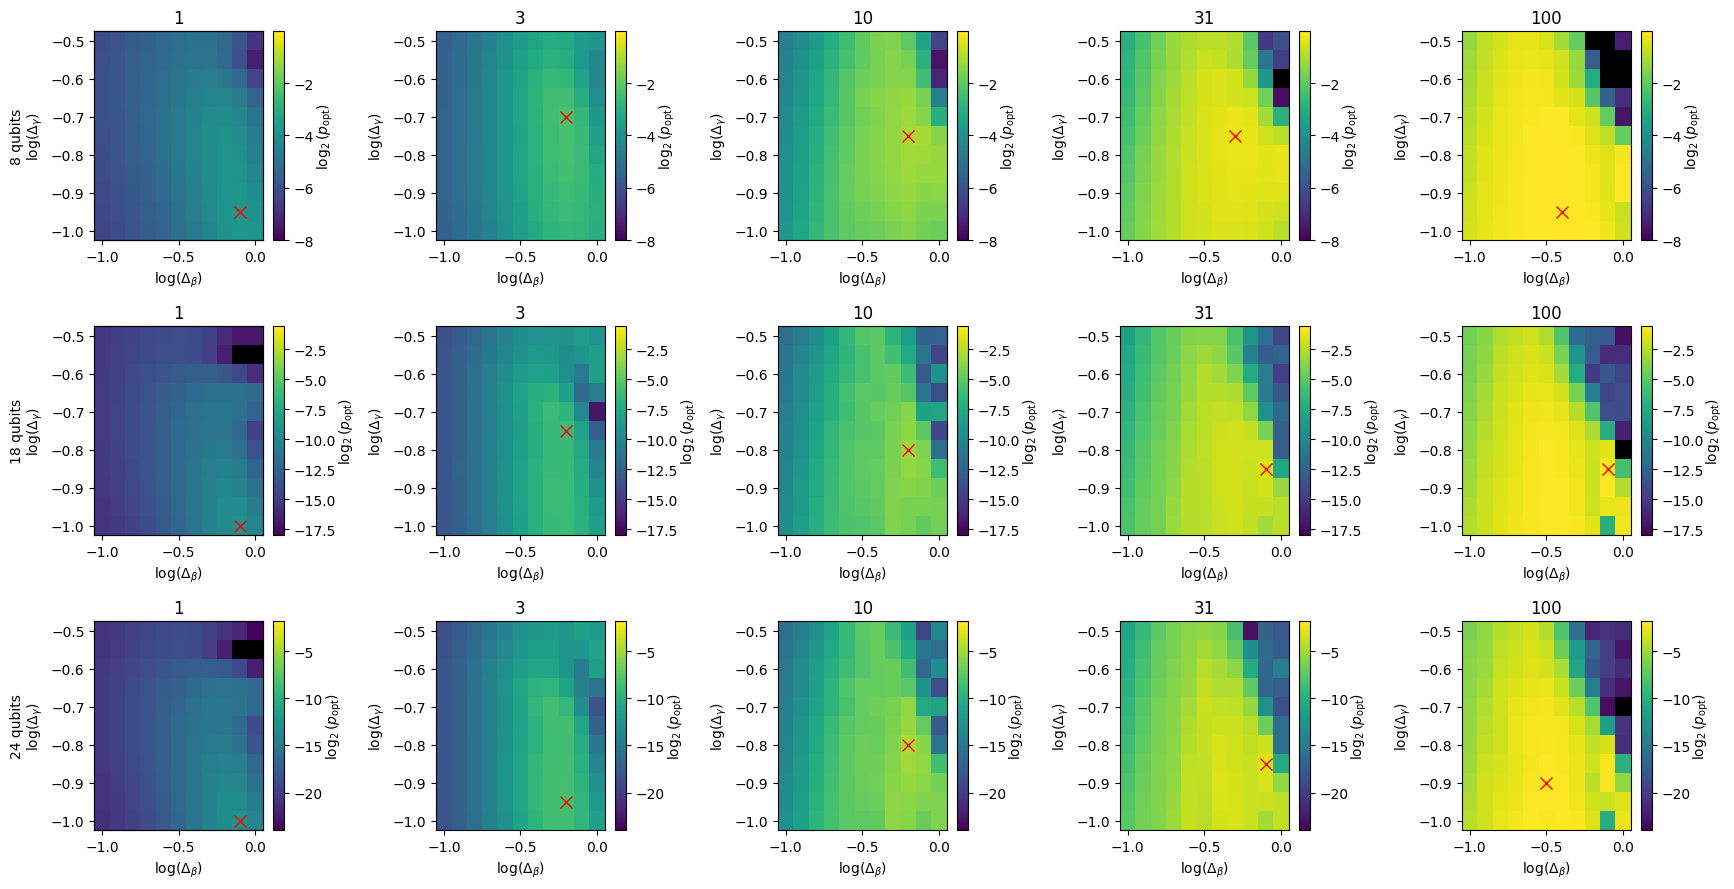

In [6]:
fig, axs = plt.subplots(3, 5)
db = 1.0
dg = 0.32
maxp = 100
qubits = [8, 18, 24]
plot_p_opt_3d(axs[0, :], 'test_N2_W2', db, dg, maxp, qubits[0])
plot_p_opt_3d(axs[1, :], 'trivial', db, dg, maxp, qubits[1])
plot_p_opt_3d(axs[2, :], 'test_N3_W4', db, dg, maxp, qubits[2])
# plot_p_opt_3d(axs[3, :], 'test_N8_W3', db, dg, maxp)
for idx, ax in enumerate(axs[:, 0]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    twin.yaxis.set_label_coords(-0.5,0.5)


fig.set_figheight(3 * len(axs[:,0]))
fig.set_figwidth(3.5 * len(axs[0,:]))
plt.tight_layout()

In [7]:
import numpy as np
from qubo_qaoa.utils.str_utils import genbin
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples_all
from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian

from qiskit.quantum_info import SparsePauliOp

# hamiltonian, ising_offset = SparsePauliOp(['ZZII', 'IIZZ', 'ZIII'], [1, 2.5, 1]), 3

filename = 'test_N2_W2'
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

_, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)

num_qubits: int = hamiltonian.num_qubits
keys = list(genbin(num_qubits))
print(np.allclose(
    evaluate_sparse_pauli_samples(keys, hamiltonian) - evaluate_sparse_pauli_samples_all(hamiltonian), 
    0
))


True


/nfs/users/nfs_j/jc59/quantumwork/pangenome/qiskit_simulation/qiskit_qaoa/utils/string_utils.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs = np.array(observable.coeffs, dtype=np.float16)


In [8]:
np.arange(6).reshape(3,2)[:, None, :].shape

(3, 1, 2)

In [9]:
hamiltonian

SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIIZZI', 'IIIIZIIZ', 'IIIIZIZI', 'IIIIZZII', 'IIIZIIIZ', 'IIIZIIZI', 'IIZIIIIZ', 'IIZIIIZI', 'IIZIZIII', 'IIZZIIII', 'IZIIIIIZ', 'IZIIIZII', 'IZIIZIII', 'IZIZIIII', 'IZZIIIII', 'ZIIIIZII', 'ZIIIZIII', 'ZIIZIIII', 'ZIZIIIII', 'ZZIIIIII'],
              coeffs=[ -9.75+0.j, -11.  +0.j, -11.  +0.j,  -9.75+0.j, -11.  +0.j,  -9.75+0.j,
  -9.75+0.j, -11.  +0.j,   5.5 +0.j,   5.  +0.j,   5.  +0.j,   5.  +0.j,
   5.  +0.j,   5.5 +0.j,   0.5 +0.j,   0.5 +0.j,   0.5 +0.j,   0.5 +0.j,
  -1.25+0.j,   5.5 +0.j,  -1.25+0.j,   0.5 +0.j,   0.5 +0.j,   5.  +0.j,
   5.  +0.j,   0.5 +0.j,   0.5 +0.j,   5.  +0.j,   5.  +0.j,   5.5 +0.j])